# Modelo predictivo de ventas – Empresa Aliada

## Predicción de ventas de Vanish y Lysol

### Objetivo

El objetivo de este proyecto es desarrollar un modelo predictivo que permita analizar las ventas históricas de productos de las marcas Vanish y Lysol y generar predicciones de ventas futuras.

Para ello se realizará la preparación y exploración de los datos, la selección de una técnica de modelado adecuada, la división de los datos en entrenamiento y prueba, la construcción y validación del modelo y, finalmente, la generación de predicciones futuras.

El desempeño del modelo será evaluado mediante métricas de error y la comparación gráfica entre los valores reales y los valores predichos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fact_sales = pd.read_csv('FACT_SALES.csv')

dim_product = pd.read_excel('DIM_PRODUCT.xlsx')
dim_calendar = pd.read_excel('DIM_CALENDAR.xlsx')
dim_segment = pd.read_excel('DIM_SEGMENT.xlsx')

In [3]:
print("FACT_SALES:", fact_sales.shape)
print("DIM_PRODUCT:", dim_product.shape)
print("DIM_CALENDAR:", dim_calendar.shape)
print("DIM_SEGMENT:", dim_segment.shape)

FACT_SALES: (122002, 6)
DIM_PRODUCT: (505, 9)
DIM_CALENDAR: (156, 5)
DIM_SEGMENT: (53, 6)


In [4]:
fact_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122002 entries, 0 to 122001
Data columns (total 6 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   WEEK                         122002 non-null  object 
 1   ITEM_CODE                    122002 non-null  object 
 2   TOTAL_UNIT_SALES             122002 non-null  float64
 3   TOTAL_VALUE_SALES            122002 non-null  float64
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64
 5   REGION                       122002 non-null  object 
dtypes: float64(3), object(3)
memory usage: 5.6+ MB


In [5]:
fact_sales.head(10)

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5
5,34-22,7501058716064,0.005,0.679,1.250,TOTAL AUTOS AREA 5
6,34-22,7501058794963BP1,0.004,0.553,1.000,TOTAL AUTOS AREA 5
7,34-22,7501058792778BP1,0.001,0.128,1.000,TOTAL AUTOS AREA 5
8,34-22,7501058757630,0.716,71.018,4.287,TOTAL AUTOS AREA 5
9,34-22,7501058753441,2.704,61.229,11.220,TOTAL AUTOS AREA 5


In [7]:
fact_sales.duplicated().sum()

np.int64(0)

In [8]:
dim_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   MANUFACTURER      505 non-null    object
 1   BRAND             505 non-null    object
 2   ITEM              503 non-null    object
 3   ITEM_DESCRIPTION  505 non-null    object
 4   CATEGORY          505 non-null    int64 
 5   FORMAT            505 non-null    object
 6   ATTR1             499 non-null    object
 7   ATTR2             505 non-null    object
 8   ATTR3             499 non-null    object
dtypes: int64(1), object(8)
memory usage: 35.6+ KB


In [10]:
dim_product[dim_product.isnull().any(axis=1)]

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
33,WHITE MAGIC,WHITE MAGIC,0079893431208,9WHITE MAGIC BOT.PLAS 3970ML IMP 0079893431208,1,LIQUIDO,NaN,CLORO,NaN
107,INDS. ALEN,CLORALEX,7501025401023,CLORALEX EXTRA SENSACION FRUTALES BOT PLAST 95...,1,LIQUIDO,NaN,CLORO,NaN
143,INDS. ALEN,BLANCATEL,7501025402259,BLANCATEL BLANQUEADOR BOTELLA 1.8LT 7501025402259,1,LIQUIDO,NaN,CLORO,NaN
343,CLOROX,CLOROX,7501071901591,CLOROX BLANQUEADOR PARAISO TROPICAL 3800 ML NA...,1,LIQUIDO,NaN,CLORO,NaN
469,OTHERS FABRICANTE UNIF.,OTHERS MARCA UNIF.,7502217411776,KLEEN CLORO BOTELLA 1000 ML NAL 7502217411776,1,LIQUIDO,NaN,CLORO,NaN
495,IBERIA,IBERIA,8411660040503,9IBERIA BLANQUEADOR POLVO 250 GR IMP 841166004...,1,POLVO,NaN,CLORO,NaN
502,INDS. ALEN,CLORALEX,NaN,CLORALEX EL RENDIDOR BOT PLAST 2LT,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
503,CLOROX,CLOROX,NaN,CLOROX MASCOTAS BLANQUEADOR+DETERGENTE GALON 10L,1,LIQUIDO,CLORO,CLORO,MASCOTAS


In [11]:
dim_product['ITEM'].duplicated().sum()

np.int64(1)

In [12]:
dim_product[
    dim_product['ITEM'].duplicated(keep=False)
][['BRAND', 'ITEM', 'ITEM_DESCRIPTION']]

,BRAND,ITEM,ITEM_DESCRIPTION
502,CLORALEX,NaN,CLORALEX EL RENDIDOR BOT PLAST 2LT
503,CLOROX,NaN,CLOROX MASCOTAS BLANQUEADOR+DETERGENTE GALON 10L


In [13]:
dim_product = dim_product.dropna(subset=['ITEM'])

In [14]:
dim_product.info()

<class 'pandas.core.frame.DataFrame'>
Index: 503 entries, 0 to 504
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   MANUFACTURER      503 non-null    object
 1   BRAND             503 non-null    object
 2   ITEM              503 non-null    object
 3   ITEM_DESCRIPTION  503 non-null    object
 4   CATEGORY          503 non-null    int64 
 5   FORMAT            503 non-null    object
 6   ATTR1             497 non-null    object
 7   ATTR2             503 non-null    object
 8   ATTR3             497 non-null    object
dtypes: int64(1), object(8)
memory usage: 39.3+ KB


In [15]:
dim_product['ITEM'].duplicated().sum()

np.int64(0)

In [16]:
dim_calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   WEEK         156 non-null    object        
 1   YEAR         156 non-null    int64         
 2   MONTH        156 non-null    int64         
 3   WEEK_NUMBER  156 non-null    int64         
 4   DATE         156 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 6.2+ KB


In [17]:
print("Duplicados completos:", dim_calendar.duplicated().sum())
print("WEEK duplicadas:", dim_calendar['WEEK'].duplicated().sum())

Duplicados completos: 0
WEEK duplicadas: 0


In [18]:
dim_calendar.head(10)

,WEEK,YEAR,MONTH,WEEK_NUMBER,DATE
0,01-21,2021,1,1,2021-01-10
1,02-21,2021,1,2,2021-01-17
2,03-21,2021,1,3,2021-01-24
3,04-21,2021,1,4,2021-01-31
4,05-21,2021,2,5,2021-02-07
5,06-21,2021,2,6,2021-02-14
6,07-21,2021,2,7,2021-02-21
7,08-21,2021,2,8,2021-02-28
8,09-21,2021,3,9,2021-03-07
9,10-21,2021,3,10,2021-03-14


In [19]:
dim_segment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   CATEGORY  53 non-null     int64 
 1   ATTR1     53 non-null     object
 2   ATTR2     53 non-null     object
 3   ATTR3     52 non-null     object
 4   FORMAT    53 non-null     object
 5   SEGMENT   53 non-null     object
dtypes: int64(1), object(5)
memory usage: 2.6+ KB


In [20]:
print("Duplicados completos:", dim_segment.duplicated().sum())

Duplicados completos: 0


In [21]:
fact_sales['ITEM_CODE'].isin(dim_product['ITEM']).value_counts()

ITEM_CODE
True    122002
Name: count, dtype: int64

In [22]:
fact_sales['WEEK'].isin(dim_calendar['WEEK']).value_counts()

WEEK
True    122002
Name: count, dtype: int64

In [23]:
ventas = fact_sales.merge(
    dim_product,
    left_on='ITEM_CODE',
    right_on='ITEM',
    how='left',
    validate='many_to_one'
)

In [24]:
ventas.shape

(122002, 15)

In [25]:
ventas = ventas.merge(
    dim_calendar,
    on='WEEK',
    how='left',
    validate='many_to_one'
)

ventas.shape

(122002, 19)

In [26]:
ventas[['WEEK', 'DATE', 'ITEM_CODE', 'BRAND', 'TOTAL_VALUE_SALES']].head(10)

,WEEK,DATE,ITEM_CODE,BRAND,TOTAL_VALUE_SALES
0,34-22,2022-08-28,7501058792808BP2,VANISH,0.139
1,34-22,2022-08-28,7501058715883,VANISH,116.519
2,34-22,2022-08-28,7702626213774,VANISH,68.453
3,34-22,2022-08-28,7501058716422,VANISH,1.481
4,34-22,2022-08-28,7501058784353,VANISH,182.839
5,34-22,2022-08-28,7501058716064,VANISH,0.679
6,34-22,2022-08-28,7501058794963BP1,VANISH,0.553
7,34-22,2022-08-28,7501058792778BP1,VANISH,0.128
8,34-22,2022-08-28,7501058757630,VANISH,71.018
9,34-22,2022-08-28,7501058753441,VANISH,61.229


In [27]:
ventas[
    ventas['BRAND'].str.contains('VANISH|LYSOL', case=False, na=False)
]['BRAND'].value_counts()

BRAND
VANISH    28377
LYSOL      3449
Name: count, dtype: int64

In [28]:
ventas_modelo = ventas[
    ventas['BRAND'].isin(['VANISH', 'LYSOL'])
].copy()

ventas_modelo.shape

(31826, 19)

In [29]:
print("Fecha mínima:", ventas_modelo['DATE'].min())
print("Fecha máxima:", ventas_modelo['DATE'].max())
print("Semanas únicas:", ventas_modelo['WEEK'].nunique())

Fecha mínima: 2022-01-09 00:00:00
Fecha máxima: 2023-07-17 00:00:00
Semanas únicas: 80


In [30]:
ventas_modelo.groupby('BRAND')['WEEK'].nunique()

BRAND
LYSOL     80
VANISH    80
Name: WEEK, dtype: int64

## Preparación de las series de ventas

Para construir las series de tiempo, se seleccionaron únicamente los registros correspondientes a las marcas Vanish y Lysol.

Posteriormente, las ventas se agruparon por semana y por marca utilizando la variable `TOTAL_VALUE_SALES`. De esta forma, los diferentes productos y regiones correspondientes a una misma marca se consolidaron en un único valor de ventas para cada semana.

Se decidió conservar una frecuencia semanal debido a que el conjunto de datos contiene 80 semanas de información. Una agregación mensual reduciría considerablemente el número de observaciones disponibles para el entrenamiento y evaluación del modelo.

In [31]:
ventas_semanales = (
    ventas_modelo
    .groupby(['DATE', 'BRAND'])['TOTAL_VALUE_SALES']
    .sum()
    .reset_index()
)

ventas_semanales.head(10)

,DATE,BRAND,TOTAL_VALUE_SALES
0,2022-01-09,LYSOL,1748.678
1,2022-01-09,VANISH,28395.363
2,2022-01-16,LYSOL,2248.498
3,2022-01-16,VANISH,26136.303
4,2022-01-23,LYSOL,2303.522
5,2022-01-23,VANISH,22343.148
6,2022-01-30,LYSOL,2263.808
7,2022-01-30,VANISH,22247.576
8,2022-02-06,LYSOL,1731.716
9,2022-02-06,VANISH,23079.228


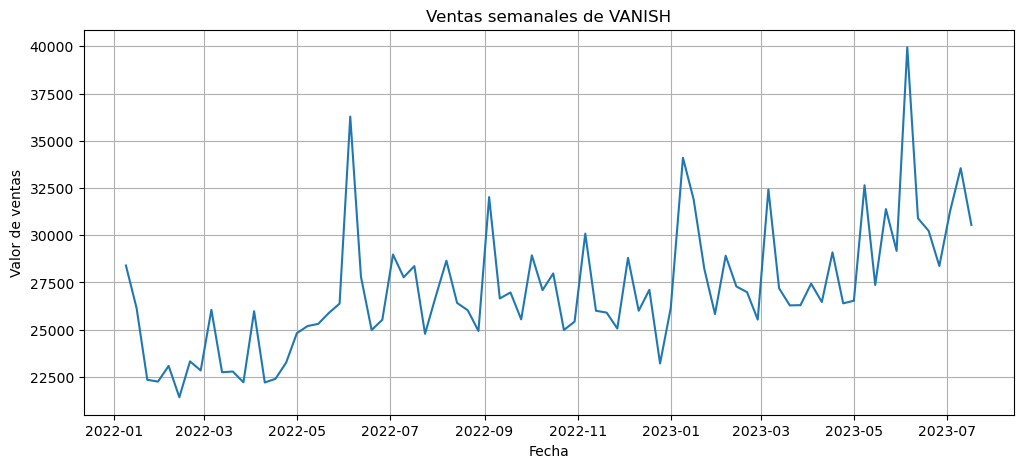

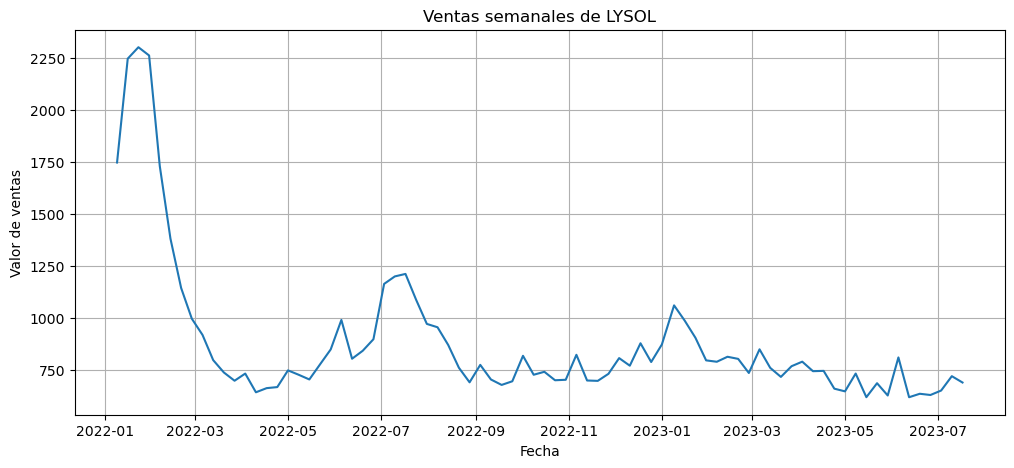

In [32]:
for marca in ['VANISH', 'LYSOL']:
    datos = ventas_semanales[ventas_semanales['BRAND'] == marca]

    plt.figure(figsize=(12, 5))
    plt.plot(datos['DATE'], datos['TOTAL_VALUE_SALES'])
    plt.title(f'Ventas semanales de {marca}')
    plt.xlabel('Fecha')
    plt.ylabel('Valor de ventas')
    plt.grid(True)
    plt.show()

In [33]:
from statsmodels.tsa.stattools import adfuller

In [34]:
vanish = ventas_semanales[
    ventas_semanales['BRAND'] == 'VANISH'
].set_index('DATE')['TOTAL_VALUE_SALES']

resultado_adf = adfuller(vanish)

print("Estadístico ADF:", resultado_adf[0])
print("p-value:", resultado_adf[1])

Estadístico ADF: -0.7907571103790587
p-value: 0.8218220306399211


In [35]:
lysol = ventas_semanales[
    ventas_semanales['BRAND'] == 'LYSOL'
].set_index('DATE')['TOTAL_VALUE_SALES']

resultado_adf_lysol = adfuller(lysol)

print("Estadístico ADF:", resultado_adf_lysol[0])
print("p-value:", resultado_adf_lysol[1])

Estadístico ADF: -2.63448487310473
p-value: 0.08607731582002393


In [36]:
vanish_diff = vanish.diff().dropna()

resultado_adf_diff = adfuller(vanish_diff)

print("Estadístico ADF:", resultado_adf_diff[0])
print("p-value:", resultado_adf_diff[1])

Estadístico ADF: -3.0905425476382864
p-value: 0.027261045194930045


In [37]:
lysol_diff = lysol.diff().dropna()

resultado_adf_lysol_diff = adfuller(lysol_diff)

print("Estadístico ADF:", resultado_adf_lysol_diff[0])
print("p-value:", resultado_adf_lysol_diff[1])

Estadístico ADF: -7.973187847773838
p-value: 2.746184997925847e-12


## Evaluación de estacionariedad

Para evaluar la estacionariedad de las series de ventas se utilizó la prueba Dickey-Fuller Aumentada (ADF).

En las series originales de Vanish y Lysol se obtuvieron valores p superiores a 0.05, por lo que no se rechazó la hipótesis nula de no estacionariedad.

Posteriormente se aplicó una primera diferenciación a cada serie. Después de esta transformación, ambas obtuvieron valores p inferiores a 0.05, indicando que las series diferenciadas pueden considerarse estacionarias.

Por lo tanto, una diferenciación es suficiente para ambas marcas, por lo que se considera inicialmente un valor d = 1 para los modelos ARIMA.

In [38]:
vanish_train = vanish.iloc[:-12]
vanish_test = vanish.iloc[-12:]

print("Entrenamiento:", len(vanish_train))
print("Prueba:", len(vanish_test))

Entrenamiento: 68
Prueba: 12


## División de los datos en entrenamiento y prueba

Para evaluar la capacidad predictiva del modelo se realizó una división temporal de los datos.

Se utilizaron las primeras 68 semanas (85%) como conjunto de entrenamiento y las últimas 12 semanas (15%) como conjunto de prueba. Se conservó el orden cronológico de las observaciones, ya que en una serie de tiempo el modelo debe utilizar información del pasado para predecir valores futuros.

In [39]:
lysol_train = lysol.iloc[:-12]
lysol_test = lysol.iloc[-12:]

print("Entrenamiento:", len(lysol_train))
print("Prueba:", len(lysol_test))

Entrenamiento: 68
Prueba: 12


In [40]:
from statsmodels.tsa.arima.model import ARIMA

In [41]:
resultados_vanish = []

for p in range(4):
    for q in range(4):
        try:
            modelo = ARIMA(vanish_train, order=(p, 1, q))
            ajuste = modelo.fit()

            resultados_vanish.append([
                p,
                1,
                q,
                ajuste.aic,
                ajuste.bic
            ])
        except:
            pass

tabla_vanish = pd.DataFrame(
    resultados_vanish,
    columns=['p', 'd', 'q', 'AIC', 'BIC']
)

tabla_vanish.sort_values('AIC')

C:\Users\el_do\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\el_do\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\el_do\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\el_do\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(d

,p,d,q,AIC,BIC
12,3,1,0,1254.650499,1263.469269
13,3,1,1,1255.802180,1266.825643
2,0,1,2,1255.993180,1262.607258
9,2,1,1,1256.564075,1265.382845
5,1,1,1,1256.792443,1263.406521
14,3,1,2,1256.818926,1270.047082
7,1,1,3,1257.482609,1268.506072
10,2,1,2,1257.725282,1268.748745
6,1,1,2,1257.931571,1266.750341
11,2,1,3,1258.221734,1271.449890


In [42]:
vanish.index.to_series().diff().value_counts()

DATE
7 days    78
8 days     1
Name: count, dtype: int64

In [43]:
diferencias = vanish.index.to_series().diff()

diferencias[diferencias != pd.Timedelta(days=7)]

DATE
2022-01-09      NaT
2023-01-09   8 days
Name: DATE, dtype: timedelta64[ns]

In [44]:
vanish.loc['2022-12-25':'2023-01-22']

DATE
2022-12-25    23209.076
2023-01-01    26142.032
2023-01-09    34099.356
2023-01-16    31897.551
Name: TOTAL_VALUE_SALES, dtype: float64

In [45]:
vanish.index = pd.date_range(
    start=vanish.index[0],
    periods=len(vanish),
    freq='7D'
)

vanish.index.freq

<7 * Days>

In [46]:
vanish_train = vanish.iloc[:-12]
vanish_test = vanish.iloc[-12:]

print("Entrenamiento:", len(vanish_train))
print("Prueba:", len(vanish_test))
print("Frecuencia:", vanish_train.index.freq)

Entrenamiento: 68
Prueba: 12
Frecuencia: <7 * Days>


### Regularización de la frecuencia temporal

Al revisar las fechas de la serie se detectó que la mayoría de las observaciones estaban separadas por 7 días, excepto un intervalo de 8 días.

Esta irregularidad impedía que `statsmodels` reconociera automáticamente la frecuencia semanal de la serie y generaba advertencias durante el ajuste de los modelos ARIMA.

Por este motivo se creó un índice temporal regular con intervalos de 7 días. Esta modificación únicamente regulariza el eje temporal utilizado por el modelo y no altera los valores de ventas ni el número de observaciones.

Posteriormente, la serie se dividió nuevamente en 68 semanas de entrenamiento y 12 semanas de prueba.

In [47]:
lysol.index = pd.date_range(
    start=lysol.index[0],
    periods=len(lysol),
    freq='7D'
)

lysol_train = lysol.iloc[:-12]
lysol_test = lysol.iloc[-12:]

print("Entrenamiento:", len(lysol_train))
print("Prueba:", len(lysol_test))
print("Frecuencia:", lysol_train.index.freq)

Entrenamiento: 68
Prueba: 12
Frecuencia: <7 * Days>


In [48]:
resultados_vanish = []

for p in range(4):
    for q in range(4):
        try:
            modelo = ARIMA(vanish_train, order=(p, 1, q))
            ajuste = modelo.fit()

            resultados_vanish.append([
                p,
                1,
                q,
                ajuste.aic,
                ajuste.bic
            ])
        except:
            pass

tabla_vanish = pd.DataFrame(
    resultados_vanish,
    columns=['p', 'd', 'q', 'AIC', 'BIC']
)

tabla_vanish.sort_values('AIC')

C:\Users\el_do\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\el_do\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\el_do\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\el_do\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,p,d,q,AIC,BIC
12,3,1,0,1254.650499,1263.469269
13,3,1,1,1255.802180,1266.825643
2,0,1,2,1255.993180,1262.607258
9,2,1,1,1256.564075,1265.382845
5,1,1,1,1256.792443,1263.406521
14,3,1,2,1256.818926,1270.047082
7,1,1,3,1257.482609,1268.506072
10,2,1,2,1257.725282,1268.748745
6,1,1,2,1257.931571,1266.750341
11,2,1,3,1258.221734,1271.449890


In [49]:
resultados_lysol = []

for p in range(4):
    for q in range(4):
        try:
            modelo = ARIMA(lysol_train, order=(p, 1, q))
            ajuste = modelo.fit()

            resultados_lysol.append([
                p,
                1,
                q,
                ajuste.aic,
                ajuste.bic
            ])
        except:
            pass

tabla_lysol = pd.DataFrame(
    resultados_lysol,
    columns=['p', 'd', 'q', 'AIC', 'BIC']
)

tabla_lysol.sort_values('AIC')

C:\Users\el_do\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\el_do\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\el_do\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\el_do\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\el_do\anaconda3\Lib\s

,p,d,q,AIC,BIC
2,0,1,2,836.537675,843.151752
10,2,1,2,836.930901,847.954364
7,1,1,3,837.249558,848.273021
12,3,1,0,837.279401,846.098171
3,0,1,3,838.455721,847.274492
11,2,1,3,838.627910,851.856065
14,3,1,2,838.768516,851.996671
13,3,1,1,839.251164,850.274627
6,1,1,2,839.695965,848.514736
4,1,1,0,840.262484,844.671870


## Selección de parámetros ARIMA

Para seleccionar los parámetros `p` y `q` se probaron diferentes combinaciones de modelos ARIMA manteniendo `d = 1`, valor previamente determinado mediante la prueba ADF.

Los modelos fueron comparados utilizando los criterios AIC y BIC, donde valores menores indican un mejor equilibrio entre ajuste y complejidad.

Para Vanish, el menor AIC correspondió al modelo ARIMA(3,1,0), mientras que el menor BIC correspondió a ARIMA(0,1,2). Por este motivo, ambos modelos se consideran candidatos y serán comparados mediante su desempeño predictivo sobre el conjunto de prueba.

Para Lysol, tanto el menor AIC como el menor BIC correspondieron al modelo ARIMA(0,1,2), por lo que este modelo se selecciona como principal candidato para la etapa de validación.

In [50]:
modelo_vanish_310 = ARIMA(
    vanish_train,
    order=(3, 1, 0)
)

ajuste_vanish_310 = modelo_vanish_310.fit()

pred_vanish_310 = ajuste_vanish_310.forecast(
    steps=len(vanish_test)
)

comparacion_vanish_310 = pd.DataFrame({
    'Real': vanish_test,
    'Predicción': pred_vanish_310
})

comparacion_vanish_310

,Real,Predicción
2023-04-30,26529.359,26906.978209
2023-05-07,32644.491,26936.163838
2023-05-14,27362.460,27532.023874
2023-05-21,31383.269,27088.547174
2023-05-28,29169.575,27052.021152
2023-06-04,39951.950,27063.888511
2023-06-11,30895.742,27206.128065
2023-06-18,30228.716,27146.310673
2023-06-25,28368.847,27114.704225
2023-07-02,31255.410,27110.099390


In [51]:
modelo_vanish_012 = ARIMA(
    vanish_train,
    order=(0, 1, 2)
)

ajuste_vanish_012 = modelo_vanish_012.fit()

pred_vanish_012 = ajuste_vanish_012.forecast(
    steps=len(vanish_test)
)

comparacion_vanish_012 = pd.DataFrame({
    'Real': vanish_test,
    'Predicción': pred_vanish_012
})

comparacion_vanish_012

,Real,Predicción
2023-04-30,26529.359,26914.251772
2023-05-07,32644.491,27249.710660
2023-05-14,27362.460,27249.710660
2023-05-21,31383.269,27249.710660
2023-05-28,29169.575,27249.710660
2023-06-04,39951.950,27249.710660
2023-06-11,30895.742,27249.710660
2023-06-18,30228.716,27249.710660
2023-06-25,28368.847,27249.710660
2023-07-02,31255.410,27249.710660


In [52]:
# Verifico que no existan ventas reales iguales a cero
print("Valores en cero:", (vanish_test == 0).sum())

Valores en cero: 0


In [55]:
# Métricas ARIMA(3,1,0)
mse_310 = mean_squared_error(vanish_test, pred_vanish_310)
mae_310 = mean_absolute_error(vanish_test, pred_vanish_310)
mape_310 = np.mean(np.abs((vanish_test - pred_vanish_310) / vanish_test)) * 100

# Métricas ARIMA(0,1,2)
mse_012 = mean_squared_error(vanish_test, pred_vanish_012)
mae_012 = mean_absolute_error(vanish_test, pred_vanish_012)
mape_012 = np.mean(np.abs((vanish_test - pred_vanish_012) / vanish_test)) * 100

comparacion_metricas_vanish = pd.DataFrame({
    'Modelo': ['ARIMA(3,1,0)', 'ARIMA(0,1,2)'],
    'MSE': [mse_310, mse_012],
    'MAE': [mae_310, mae_012],
    'MAPE (%)': [mape_310, mape_012]
})

comparacion_metricas_vanish

,Modelo,MSE,MAE,MAPE (%)
0,"ARIMA(3,1,0)",2.635689e+07,3961.399233,11.899414
1,"ARIMA(0,1,2)",2.511429e+07,3832.456793,11.492335


In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

### Validación del modelo para Vanish

Se compararon los modelos ARIMA(3,1,0) y ARIMA(0,1,2) utilizando las últimas 12 semanas como conjunto de prueba.

El modelo ARIMA(0,1,2) presentó menores valores de MSE, MAE y MAPE. Su MAPE fue de aproximadamente 11.49 %, frente a 11.90 % del modelo ARIMA(3,1,0).

Por lo tanto, se seleccionó ARIMA(0,1,2) como el modelo final para Vanish, ya que mostró un mejor desempeño predictivo sobre datos no utilizados durante el entrenamiento.

In [56]:
modelo_lysol_012 = ARIMA(
    lysol_train,
    order=(0, 1, 2)
)

ajuste_lysol_012 = modelo_lysol_012.fit()

pred_lysol_012 = ajuste_lysol_012.forecast(
    steps=len(lysol_test)
)

comparacion_lysol_012 = pd.DataFrame({
    'Real': lysol_test,
    'Predicción': pred_lysol_012
})

comparacion_lysol_012

,Real,Predicción
2023-04-30,647.376,652.906138
2023-05-07,733.120,625.078343
2023-05-14,619.315,625.078343
2023-05-21,686.638,625.078343
2023-05-28,627.476,625.078343
2023-06-04,810.651,625.078343
2023-06-11,619.176,625.078343
2023-06-18,635.810,625.078343
2023-06-25,629.895,625.078343
2023-07-02,651.383,625.078343


In [57]:
print("Valores en cero:", (lysol_test == 0).sum())

Valores en cero: 0


In [58]:
mse_lysol = mean_squared_error(lysol_test, pred_lysol_012)
mae_lysol = mean_absolute_error(lysol_test, pred_lysol_012)
mape_lysol = np.mean(
    np.abs((lysol_test - pred_lysol_012) / lysol_test)
) * 100

print("MSE:", mse_lysol)
print("MAE:", mae_lysol)
print("MAPE (%):", mape_lysol)

MSE: 5345.532078412879
MAE: 48.07656167867892
MAPE (%): 6.571059688439508


### Validación del modelo para Lysol

El modelo ARIMA(0,1,2) fue evaluado utilizando las últimas 12 semanas como conjunto de prueba.

Se obtuvo un MSE de 5,345.53, un MAE de 48.08 y un MAPE de aproximadamente 6.57 %. Esto indica que las predicciones del modelo se desviaron de las ventas reales aproximadamente un 6.57 % en promedio.

El desempeño predictivo obtenido para Lysol fue mejor que el observado para Vanish, cuyo modelo seleccionado presentó un MAPE aproximado de 11.49 %.

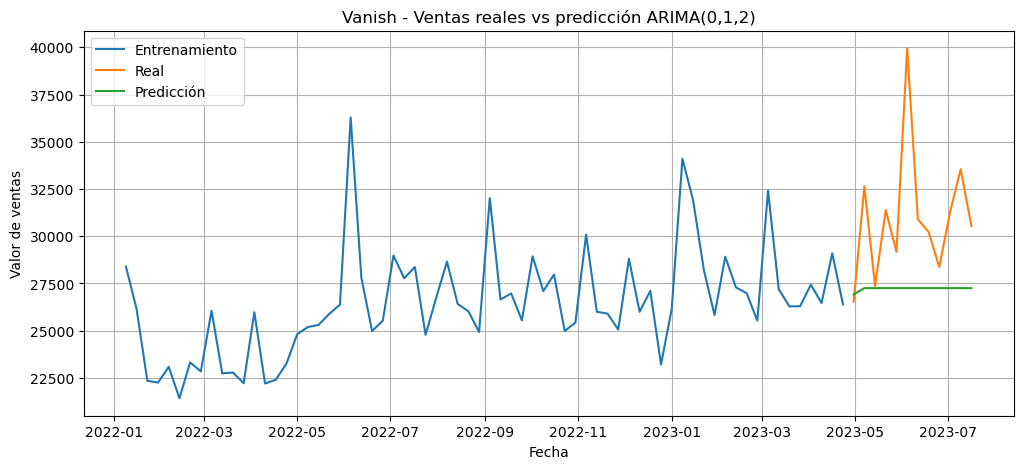

In [59]:
plt.figure(figsize=(12, 5))

plt.plot(vanish_train.index, vanish_train, label='Entrenamiento')
plt.plot(vanish_test.index, vanish_test, label='Real')
plt.plot(pred_vanish_012.index, pred_vanish_012, label='Predicción')

plt.title('Vanish - Ventas reales vs predicción ARIMA(0,1,2)')
plt.xlabel('Fecha')
plt.ylabel('Valor de ventas')
plt.legend()
plt.grid(True)
plt.show()

### Interpretación de la predicción de Vanish

La gráfica compara las ventas utilizadas para el entrenamiento con las 12 semanas reservadas para prueba y las predicciones generadas por el modelo ARIMA(0,1,2).

Se observa que el modelo logra aproximarse al nivel general de ventas de Vanish; sin embargo, las predicciones permanecen prácticamente constantes alrededor de 27,250. Por esta razón, el modelo no logra reproducir completamente las fluctuaciones ni los picos presentes en las ventas reales.

A pesar de esta limitación, el modelo obtuvo un MAPE aproximado de 11.49 % en el conjunto de prueba.

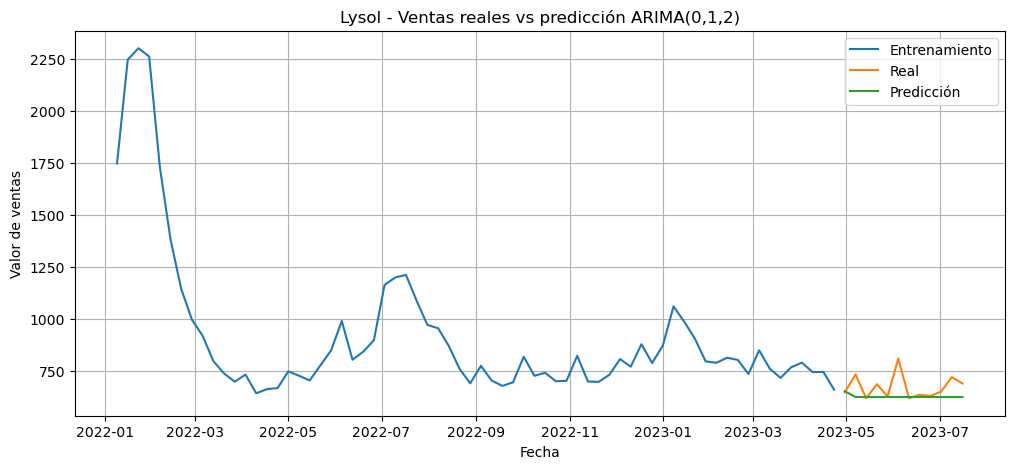

In [60]:
plt.figure(figsize=(12, 5))

plt.plot(lysol_train.index, lysol_train, label='Entrenamiento')
plt.plot(lysol_test.index, lysol_test, label='Real')
plt.plot(pred_lysol_012.index, pred_lysol_012, label='Predicción')

plt.title('Lysol - Ventas reales vs predicción ARIMA(0,1,2)')
plt.xlabel('Fecha')
plt.ylabel('Valor de ventas')
plt.legend()
plt.grid(True)
plt.show()

### Interpretación de la predicción de Lysol

La serie histórica de Lysol presenta una fuerte disminución en las ventas durante los primeros meses analizados, seguida de un periodo de mayor estabilidad.

En las 12 semanas utilizadas como conjunto de prueba, el modelo ARIMA(0,1,2) genera predicciones relativamente constantes alrededor de 625. Aunque el modelo no reproduce completamente las fluctuaciones y algunos picos semanales, las predicciones se mantienen próximas al nivel general de las ventas reales.

El modelo obtuvo un MAPE aproximado de 6.57 %, mostrando un mejor desempeño predictivo que el modelo utilizado para Vanish.

In [61]:
modelo_final_vanish = ARIMA(
    vanish,
    order=(0, 1, 2)
)

ajuste_final_vanish = modelo_final_vanish.fit()

print(ajuste_final_vanish.aic)

1494.007316910754


In [62]:
pronostico_futuro_vanish = ajuste_final_vanish.forecast(steps=15)

pronostico_futuro_vanish

2023-07-23    30905.968221
2023-07-30    31070.811522
2023-08-06    31070.811522
2023-08-13    31070.811522
2023-08-20    31070.811522
2023-08-27    31070.811522
2023-09-03    31070.811522
2023-09-10    31070.811522
2023-09-17    31070.811522
2023-09-24    31070.811522
2023-10-01    31070.811522
2023-10-08    31070.811522
2023-10-15    31070.811522
2023-10-22    31070.811522
2023-10-29    31070.811522
Freq: 7D, Name: predicted_mean, dtype: float64

### Pronóstico futuro de Vanish

Una vez seleccionado y validado el modelo ARIMA(0,1,2), se realizó un nuevo ajuste utilizando las 80 semanas disponibles y se generaron pronósticos futuros.

Las predicciones semanales tienden a estabilizarse alrededor de 31,071 en valor de ventas. Este comportamiento indica que el modelo estima adecuadamente un nivel general de ventas, aunque presenta una capacidad limitada para anticipar fluctuaciones o picos semanales.

In [64]:
pronostico_mensual_vanish = (
    pronostico_futuro_vanish
    .to_frame(name='Predicción')
    .assign(Mes=lambda x: x.index.to_period('M'))
    .groupby('Mes')['Predicción']
    .sum()
)

# se excluye julio porque el pronóstico mensual está incompleto
pronostico_mensual_vanish = pronostico_mensual_vanish[
    pronostico_mensual_vanish.index >= '2023-08'
]

pronostico_mensual_vanish

Mes
2023-08    124283.246087
2023-09    124283.246087
2023-10    155354.057609
Freq: M, Name: Predicción, dtype: float64

### Pronóstico mensual de Vanish

A partir de las predicciones semanales del modelo ARIMA(0,1,2), se estimaron las ventas mensuales para agosto, septiembre y octubre de 2023.

Los resultados muestran un nivel de ventas semanales relativamente estable. El mayor valor acumulado observado en octubre no representa necesariamente un crecimiento en las ventas, sino que se debe a que dicho mes contiene cinco observaciones semanales dentro del horizonte de pronóstico, mientras que agosto y septiembre contienen cuatro.

Por lo tanto, el modelo sugiere estabilidad en el nivel general de ventas futuras de Vanish.

In [65]:
modelo_final_lysol = ARIMA(
    lysol,
    order=(0, 1, 2)
)

ajuste_final_lysol = modelo_final_lysol.fit()

print(ajuste_final_lysol.aic)

983.3365086870087


In [66]:
pronostico_futuro_lysol = ajuste_final_lysol.forecast(steps=15)

pronostico_futuro_lysol

2023-07-23    695.235587
2023-07-30    680.056314
2023-08-06    680.056314
2023-08-13    680.056314
2023-08-20    680.056314
2023-08-27    680.056314
2023-09-03    680.056314
2023-09-10    680.056314
2023-09-17    680.056314
2023-09-24    680.056314
2023-10-01    680.056314
2023-10-08    680.056314
2023-10-15    680.056314
2023-10-22    680.056314
2023-10-29    680.056314
Freq: 7D, Name: predicted_mean, dtype: float64

In [67]:
pronostico_mensual_lysol = (
    pronostico_futuro_lysol
    .to_frame(name='Predicción')
    .assign(Mes=lambda x: x.index.to_period('M'))
    .groupby('Mes')['Predicción']
    .sum()
)

# Excluimos julio porque está incompleto
pronostico_mensual_lysol = pronostico_mensual_lysol[
    pronostico_mensual_lysol.index >= '2023-08'
]

pronostico_mensual_lysol

Mes
2023-08    2720.225256
2023-09    2720.225256
2023-10    3400.281570
Freq: M, Name: Predicción, dtype: float64

### Pronóstico futuro de Lysol

El modelo ARIMA(0,1,2), reentrenado con las 80 semanas disponibles, genera un pronóstico semanal que se estabiliza alrededor de 680 en valor de ventas.

Al agregar las predicciones por mes, se obtienen valores aproximados de 2,720 para agosto y septiembre y 3,400 para octubre. El mayor valor de octubre se debe a que contiene cinco observaciones semanales dentro del horizonte de pronóstico, por lo que no debe interpretarse directamente como un crecimiento de las ventas.

In [68]:
pronostico_mensual = pd.DataFrame({
    'VANISH': pronostico_mensual_vanish,
    'LYSOL': pronostico_mensual_lysol
})

pronostico_mensual

,VANISH,LYSOL
Mes,,
2023-08,124283.246087,2720.225256
2023-09,124283.246087,2720.225256
2023-10,155354.057609,3400.281570


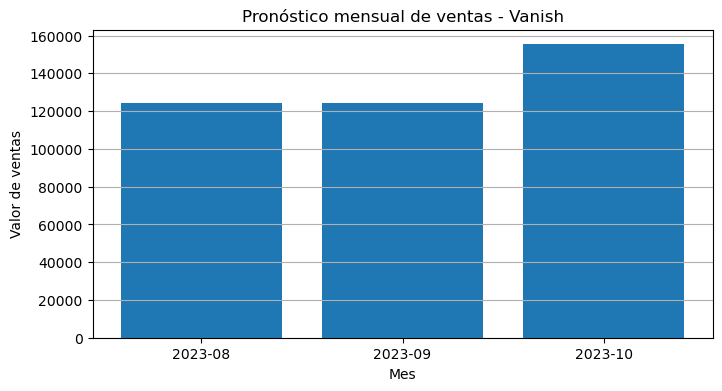

In [69]:
plt.figure(figsize=(8, 4))

plt.bar(
    pronostico_mensual.index.astype(str),
    pronostico_mensual['VANISH']
)

plt.title('Pronóstico mensual de ventas - Vanish')
plt.xlabel('Mes')
plt.ylabel('Valor de ventas')
plt.grid(axis='y')
plt.show()

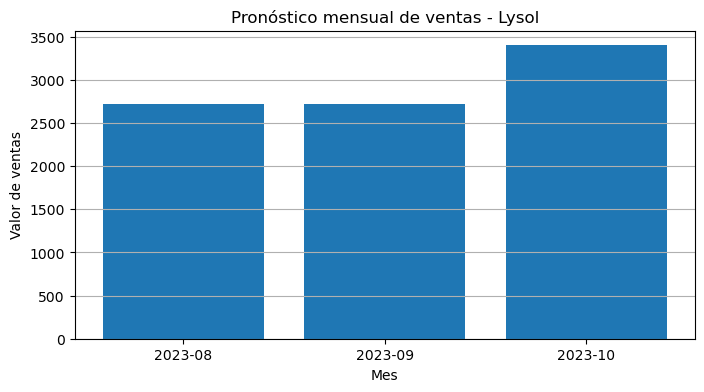

In [70]:
plt.figure(figsize=(8, 4))

plt.bar(
    pronostico_mensual.index.astype(str),
    pronostico_mensual['LYSOL']
)

plt.title('Pronóstico mensual de ventas - Lysol')
plt.xlabel('Mes')
plt.ylabel('Valor de ventas')
plt.grid(axis='y')
plt.show()

## Selección de la técnica de modelado

Se seleccionó un modelo ARIMA debido a que el objetivo del análisis es pronosticar las ventas futuras a partir de su comportamiento histórico en el tiempo.

Se conservaron los datos con frecuencia semanal, obteniendo 80 observaciones para cada marca. No se utilizó una regresión múltiple debido a que el conjunto de datos no contiene variables explicativas futuras, como promociones, precios o inversión publicitaria, que permitan construir predicciones para periodos posteriores.

Tampoco se utilizó un modelo SARIMA con estacionalidad anual, ya que se dispone de menos de dos ciclos anuales completos de información semanal, lo que limita la estimación confiable de una estacionalidad de 52 semanas.

Por estas razones, se consideró ARIMA como una alternativa adecuada para realizar el pronóstico de ventas de Vanish y Lysol.

## Optimización y selección final de los modelos

Para optimizar los modelos se probaron diferentes combinaciones de los parámetros `p` y `q`, manteniendo `d = 1`, valor determinado previamente mediante la prueba ADF.

Las combinaciones fueron comparadas inicialmente mediante los criterios AIC y BIC y posteriormente mediante su desempeño sobre las 12 semanas reservadas como conjunto de prueba.

Para Vanish, ARIMA(3,1,0) presentó el menor AIC. Sin embargo, al compararlo con ARIMA(0,1,2) sobre el conjunto de prueba, este último obtuvo mejores métricas predictivas:

- ARIMA(3,1,0): MAPE ≈ 11.90 %
- ARIMA(0,1,2): MAPE ≈ 11.49 %

Por esta razón se seleccionó ARIMA(0,1,2) como modelo final para Vanish.

Para Lysol, ARIMA(0,1,2) presentó tanto el menor AIC como el menor BIC y posteriormente obtuvo un MAPE aproximado de 6.57 % sobre el conjunto de prueba, por lo que también fue seleccionado como modelo final.

Después de la validación, ambos modelos fueron reentrenados utilizando las 80 semanas disponibles antes de generar los pronósticos futuros.

## Conclusiones y recomendaciones

Se desarrollaron modelos ARIMA para pronosticar las ventas de Vanish y Lysol utilizando 80 semanas de información histórica.

Para ambas marcas se seleccionó finalmente un modelo ARIMA(0,1,2). Durante la validación, Vanish obtuvo un MAPE aproximado de 11.49 %, mientras que Lysol obtuvo un MAPE de 6.57 %, mostrando este último una mayor precisión relativa.

Los pronósticos futuros muestran un nivel de ventas relativamente estable para ambas marcas. Sin embargo, los modelos tienden a generar predicciones constantes y no logran anticipar completamente los picos o fluctuaciones semanales observados en las ventas reales.

Los pronósticos pueden utilizarse como una referencia base para la planeación de ventas e inventarios. Se recomienda actualizar periódicamente los modelos conforme se incorporen nuevas semanas de información.

Como mejora futura, podrían incorporarse variables adicionales como precios, promociones, temporadas comerciales o inversión publicitaria. Estas variables podrían ayudar a explicar las fluctuaciones que un modelo basado únicamente en el comportamiento histórico de las ventas no logra anticipar.